### Skew-t Cumulative Probability Plot and Fit, with Comparisons
For a set of values, fit to an Azzalini skew-t distribution via method of quantiles. Also fits normal and lognormal (MLE) for comparison.

#### Method
- **Fix nu** (degrees of freedom) -- controls tail heaviness; held constant because small samples can't reliably estimate it.
- **Fit alpha** via root-finding -- the skew shape parameter, solved by matching the Bowley skew of the data in standardized (mu=0, sigma=1) form.
- **Fit sigma** directly from IQR -- the scale parameter, computed as the ratio of the empirical IQR to the model's standardized IQR at the solved alpha.
- **Fit mu** directly from median -- the location parameter, set so the model's median exactly equals the data's median.
- **Optional CvM refinement** -- jointly re-optimizes (sigma, alpha) to minimize the Cramer-von Mises distance between the fitted CDF and the empirical CDF, while keeping the median hard-constrained.

#### Key Links
- [Azzalini skew-t overview (author's site)](https://azzalini.stat.unipd.it/SN/)
- [Bowley skewness (Wikipedia)](https://en.wikipedia.org/wiki/Skewness#Quantile-based_measures)
- [Cramer-von Mises statistic (Wikipedia)](https://en.wikipedia.org/wiki/Cram%C3%A9r%E2%80%93von_Mises_criterion)
- [scipy.stats.t (PDF/CDF primitives used here)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html)
- Full implementation notebook: `001 Skew-t Fitting - Method of Quantiles.ipynb`

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import brentq, minimize
from scipy.special import gamma as gamma_func

### Core skew-t functions

In [2]:
def skewt_pdf_standardized(z, alpha, nu):
    """Standardized (mu=0, sigma=1) Azzalini skew-t PDF."""
    z = np.asarray(z)
    t_arg = alpha * z * np.sqrt((nu + 1) / (z**2 + nu))
    return 2 * stats.t.pdf(z, nu) * stats.t.cdf(t_arg, nu + 1)


def skewt_pdf(x, mu, sigma, alpha, nu):
    """Azzalini skew-t PDF in real units."""
    z = (np.asarray(x) - mu) / sigma
    return skewt_pdf_standardized(z, alpha, nu) / sigma


def build_cdf_grid(alpha, nu, n_grid=2000, z_lo=-12, z_hi=12):
    """Precompute standardized CDF on a dense grid via cumulative_trapezoid."""
    z_grid = np.linspace(z_lo, z_hi, n_grid)
    pdf_vals = skewt_pdf_standardized(z_grid, alpha, nu)
    cdf_grid = cumulative_trapezoid(pdf_vals, z_grid, initial=0)
    cdf_grid /= cdf_grid[-1]
    return z_grid, cdf_grid


def skewt_cdf(x_arr, mu, sigma, alpha, nu, n_grid=2000):
    """Fast skew-t CDF via grid interpolation."""
    z_arr = (np.atleast_1d(np.asarray(x_arr, dtype=float)) - mu) / sigma
    z_grid, cdf_grid = build_cdf_grid(alpha, nu, n_grid)
    return np.interp(z_arr, z_grid, cdf_grid)


def skewt_ppf(p, mu, sigma, alpha, nu, n_grid=2000):
    """Skew-t quantile function via CDF grid interpolation."""
    z_grid, cdf_grid = build_cdf_grid(alpha, nu, n_grid)
    p_arr = np.atleast_1d(p)
    z_vals = np.interp(p_arr, cdf_grid, z_grid)
    x_vals = mu + sigma * z_vals
    return x_vals[0] if np.ndim(p) == 0 else x_vals


def skewt_ppf_fast(p, alpha, nu, z_grid, cdf_grid):
    """Fast standardized PPF from precomputed grid."""
    return np.interp(p, cdf_grid, z_grid)

### Fitting functions

In [3]:
def compute_robust_stats(x):
    """Compute robust summary statistics: median, IQR, Bowley skew."""
    m = np.median(x)
    q10, q25, q75, q90 = np.percentile(x, [10, 25, 75, 90])
    iqr = q75 - q25
    denom_90 = q90 - q10
    bowley_90 = (q90 + q10 - 2 * m) / denom_90 if denom_90 > 0 else 0.0
    denom_75 = q75 - q25
    bowley_75 = (q75 + q25 - 2 * m) / denom_75 if denom_75 > 0 else 0.0
    return {
        'median': m, 'iqr': iqr,
        'q10': q10, 'q25': q25, 'q75': q75, 'q90': q90,
        'bowley_skew_90': bowley_90, 'bowley_skew_75': bowley_75,
        'moment_skew': stats.skew(x), 'n': len(x)
    }


def fit_skewt_quantiles(x, nu, skew_target):
    """Fit skew-t via method of quantiles: alpha -> sigma -> mu."""
    emp_median = np.median(x)
    emp_iqr = np.percentile(x, 75) - np.percentile(x, 25)
    if emp_iqr < 1e-10:
        raise ValueError('IQR ~ 0: data too clustered for skew-t fitting.')

    def bowley_model(alpha):
        zg, cg = build_cdf_grid(alpha, nu, n_grid=1500)
        q10 = skewt_ppf_fast(0.1, alpha, nu, zg, cg)
        q50 = skewt_ppf_fast(0.5, alpha, nu, zg, cg)
        q90 = skewt_ppf_fast(0.9, alpha, nu, zg, cg)
        d = q90 - q10
        return (q90 + q10 - 2*q50) / d if abs(d) > 1e-12 else 0.0

    skew_lo, skew_hi = bowley_model(-10), bowley_model(10)
    if skew_target <= skew_lo:
        alpha = -10.0
    elif skew_target >= skew_hi:
        alpha = 10.0
    else:
        alpha = brentq(lambda a: bowley_model(a) - skew_target, -10, 10, xtol=1e-6)

    zg, cg = build_cdf_grid(alpha, nu, n_grid=1500)
    model_iqr_std = skewt_ppf_fast(0.75, alpha, nu, zg, cg) - skewt_ppf_fast(0.25, alpha, nu, zg, cg)
    sigma = emp_iqr / model_iqr_std

    m_std = skewt_ppf_fast(0.5, alpha, nu, zg, cg)
    mu = emp_median - sigma * m_std

    n_pts = len(x)
    x_sorted = np.sort(x)
    ecdf = (np.arange(1, n_pts + 1) - 0.5) / n_pts
    cvm = np.sum((skewt_cdf(x_sorted, mu, sigma, alpha, nu) - ecdf)**2)

    return {'mu': mu, 'sigma': sigma, 'alpha': alpha, 'nu': nu,
            'skew_target': skew_target, 'skew_model': bowley_model(alpha),
            'iqr_emp': emp_iqr, 'median_emp': emp_median, 'cvm': cvm, 'n': n_pts}


def refine_cvm(x, fit_init):
    """Refine fit by minimizing CvM distance. Median stays hard-constrained."""
    nu = fit_init['nu']
    emp_median = np.median(x)
    x_sorted = np.sort(x)
    n = len(x)
    ecdf = (np.arange(1, n + 1) - 0.5) / n

    def objective(params):
        sigma, alpha = params
        if sigma <= 0:
            return 1e10
        zg, cg = build_cdf_grid(alpha, nu, n_grid=1000)
        m_std = skewt_ppf_fast(0.5, alpha, nu, zg, cg)
        mu = emp_median - sigma * m_std
        return np.sum((skewt_cdf(x_sorted, mu, sigma, alpha, nu, n_grid=1500) - ecdf)**2)

    result = minimize(objective, [fit_init['sigma'], fit_init['alpha']],
                      method='Nelder-Mead', options={'xatol': 1e-5, 'fatol': 1e-8, 'maxiter': 200})
    sigma_r, alpha_r = result.x

    zg, cg = build_cdf_grid(alpha_r, nu, n_grid=1500)
    m_std = skewt_ppf_fast(0.5, alpha_r, nu, zg, cg)
    mu_r = emp_median - sigma_r * m_std

    q10_s = skewt_ppf_fast(0.1, alpha_r, nu, zg, cg)
    q50_s = skewt_ppf_fast(0.5, alpha_r, nu, zg, cg)
    q90_s = skewt_ppf_fast(0.9, alpha_r, nu, zg, cg)
    d = q90_s - q10_s
    bowley_r = (q90_s + q10_s - 2*q50_s) / d if abs(d) > 1e-12 else 0.0

    cvm_r = np.sum((skewt_cdf(x_sorted, mu_r, sigma_r, alpha_r, nu) - ecdf)**2)

    return {'mu': mu_r, 'sigma': sigma_r, 'alpha': alpha_r, 'nu': nu,
            'skew_target': fit_init['skew_target'], 'skew_model': bowley_r,
            'iqr_emp': fit_init['iqr_emp'], 'median_emp': emp_median,
            'cvm': cvm_r, 'cvm_before': fit_init['cvm'], 'n': fit_init['n']}


def compute_cvm(x, cdf_func):
    """CvM distance between empirical CDF and a model CDF function."""
    x_sorted = np.sort(x)
    n = len(x)
    ecdf = (np.arange(1, n + 1) - 0.5) / n
    return np.sum((cdf_func(x_sorted) - ecdf)**2)

### Example input data

In [4]:
# Example: right-skewed data from lognormal(mean=2, sigma=0.5)
rng = np.random.default_rng(42)
LN_MEAN, LN_SIGMA = 2, 0.5  # theoretical lognormal parameters (for validation only)
data = rng.lognormal(mean=LN_MEAN, sigma=LN_SIGMA, size=54)

### Inputs

In [5]:
# Inputs
x = data
nu = 5                     # degrees of freedom (fixed; try 5 or 7)
USE_CVM_REFINEMENT = True  # optional CvM refinement after quantile fit

# Set to known generator params for validation, or None to skip
THEORETICAL_LN = (LN_MEAN, LN_SIGMA)  # (mu_log, sigma_log) or None

key_pctls = np.array([1, 5, 10, 25, 50, 75, 90, 95, 99])

### Robust statistics

In [6]:
robust = compute_robust_stats(x)
n = robust['n']

print(f'n = {n}')
print(f'Median:      {robust["median"]:.4g}')
print(f'IQR:         {robust["iqr"]:.4g}')
print(f'Bowley(90):  {robust["bowley_skew_90"]:+.4f}')
print(f'Bowley(75):  {robust["bowley_skew_75"]:+.4f}')
print(f'Moment skew: {robust["moment_skew"]:+.4f}')

bowley_diff = abs(robust['bowley_skew_90'] - robust['bowley_skew_75'])
if bowley_diff > 0.15:
    print(f'  WARNING: Bowley(90) vs Bowley(75) differ by {bowley_diff:.3f} > 0.15 -- tails poorly determined')

n = 54
Median:      8.06
IQR:         4.131
Bowley(90):  +0.0242
Bowley(75):  -0.0064
Moment skew: +1.2766


### Fit all distributions

In [7]:
x_sorted = np.sort(x)
ecdf_positions = (np.arange(1, n + 1) - 0.5) / n

# --- Skew-t fit ---
skew_target = robust['bowley_skew_90']
fit = fit_skewt_quantiles(x, nu, skew_target)
if USE_CVM_REFINEMENT:
    fit = refine_cvm(x, fit)
mu, sigma, alpha = fit['mu'], fit['sigma'], fit['alpha']
cvm_skewt = fit['cvm']

# --- Normal MLE fit ---
norm_mu, norm_sigma = stats.norm.fit(x)
cvm_norm = compute_cvm(x, lambda v: stats.norm.cdf(v, norm_mu, norm_sigma))

# --- Lognormal MLE fit (only if all data > 0) ---
has_lognormal = np.all(x > 0)
if has_lognormal:
    ln_shape, ln_loc, ln_scale = stats.lognorm.fit(x, floc=0)
    cvm_lognorm = compute_cvm(x, lambda v: stats.lognorm.cdf(v, ln_shape, ln_loc, ln_scale))
else:
    print('Lognormal: skipped (data contains values <= 0)')
    cvm_lognorm = np.nan

# --- Theoretical lognormal (validation only) ---
has_theoretical = THEORETICAL_LN is not None
if has_theoretical:
    theo_mu_log, theo_sigma_log = THEORETICAL_LN
    cvm_theo = compute_cvm(x, lambda v: stats.lognorm.cdf(v, theo_sigma_log, 0, np.exp(theo_mu_log)))

# --- Print results ---
print(f'Skew-t (nu={nu}):  mu={mu:.4g}, sigma={sigma:.4g}, alpha={alpha:+.4f}, CvM={cvm_skewt:.4f}')
if 'cvm_before' in fit:
    print(f'  CvM before refinement = {fit["cvm_before"]:.4f}')
if abs(alpha) > 50:
    print(f'  WARNING: |alpha| = {abs(alpha):.1f} > 50 -- fit may be degenerate')

print(f'Normal (MLE):  mu={norm_mu:.4g}, sigma={norm_sigma:.4g}, CvM={cvm_norm:.4f}')

if has_lognormal:
    print(f'Lognormal (MLE):  mu_log={np.log(ln_scale):.4g}, sigma_log={ln_shape:.4g}, CvM={cvm_lognorm:.4f}')

if has_theoretical:
    print(f'Theoretical LN:  mu_log={theo_mu_log}, sigma_log={theo_sigma_log}, CvM={cvm_theo:.4f}')

Skew-t (nu=5):  mu=8.006, sigma=2.705, alpha=+0.0239, CvM=0.0285
  CvM before refinement = 0.0326
Normal (MLE):  mu=8.217, sigma=3.187, CvM=0.0492
Lognormal (MLE):  mu_log=2.034, sigma_log=0.3836, CvM=0.0531
Theoretical LN:  mu_log=2, sigma_log=0.5, CvM=0.1997


### Fit comparison summary

In [8]:
# Build comparison dataframe
comparison_rows = [
    {'distribution': f'Skew-t (nu={nu})',
     'param_1': f'mu={mu:.4g}', 'param_2': f'sigma={sigma:.4g}', 'param_3': f'alpha={alpha:+.4f}',
     'CvM': cvm_skewt},
    {'distribution': 'Normal (MLE)',
     'param_1': f'mu={norm_mu:.4g}', 'param_2': f'sigma={norm_sigma:.4g}', 'param_3': '',
     'CvM': cvm_norm},
]
if has_lognormal:
    comparison_rows.append(
        {'distribution': 'Lognormal (MLE)',
         'param_1': f'mu_log={np.log(ln_scale):.4g}', 'param_2': f'sig_log={ln_shape:.4g}', 'param_3': '',
         'CvM': cvm_lognorm})
if has_theoretical:
    comparison_rows.append(
        {'distribution': 'Theoretical LN',
         'param_1': f'mu_log={theo_mu_log}', 'param_2': f'sig_log={theo_sigma_log}', 'param_3': '',
         'CvM': cvm_theo})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('CvM').reset_index(drop=True)
comparison_df.index.name = 'rank'
comparison_df

,distribution,param_1,param_2,param_3,CvM
rank,,,,,
0,Skew-t (nu=5),mu=8.006,sigma=2.705,alpha=+0.0239,0.028522
1,Normal (MLE),mu=8.217,sigma=3.187,,0.049218
2,Lognormal (MLE),mu_log=2.034,sig_log=0.3836,,0.053055
3,Theoretical LN,mu_log=2,sig_log=0.5,,0.199707


### Key percentile values from skew-t fit

In [9]:
key_values = skewt_ppf(key_pctls / 100, mu, sigma, alpha, nu)

key_points_df = pd.DataFrame({'percentile': key_pctls, 'value': key_values})
key_points_df

,percentile,value
0,1,-0.990219
1,5,2.629297
2,10,4.078903
3,25,6.097094
4,50,8.059811
5,75,10.028098
6,90,12.062152
7,95,13.527776
8,99,17.196414


### CDF and PDF plots with comparisons

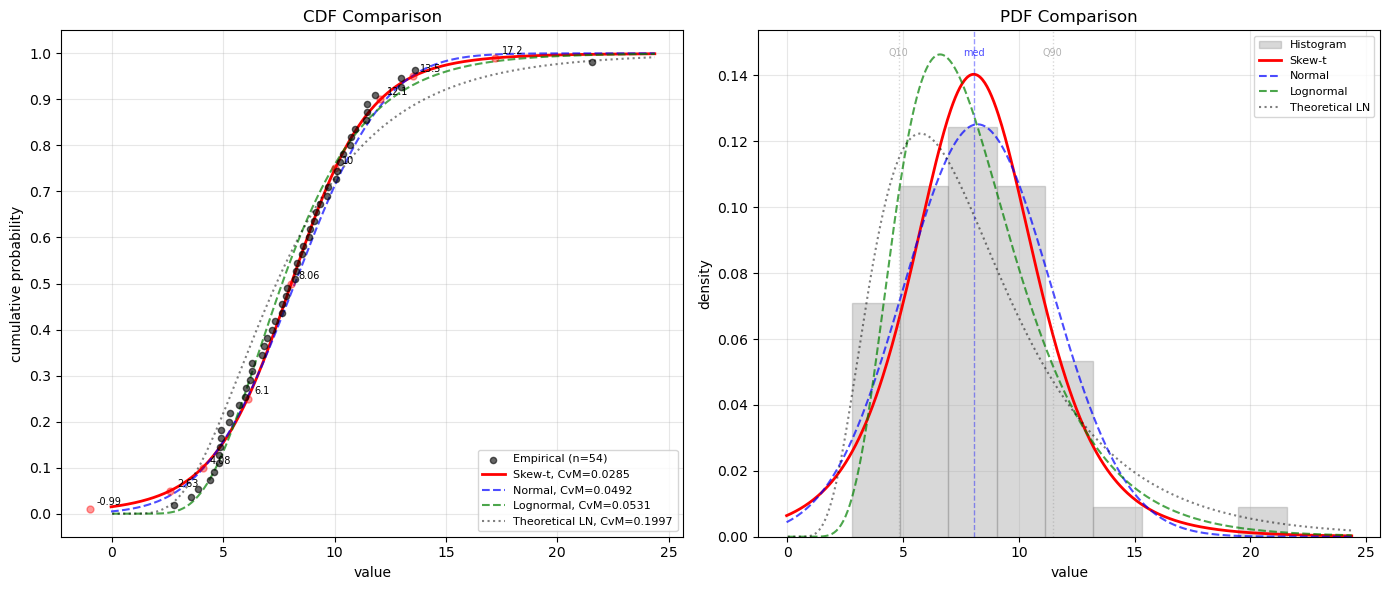

In [10]:
pad = 0.15 * (x_sorted[-1] - x_sorted[0])
x_lo = x_sorted[0] - pad
x_hi = x_sorted[-1] + pad
x_plot = np.linspace(x_lo, x_hi, 500)

ecdf_y = np.arange(1, n + 1) / (n + 1)

fig, (ax_cdf, ax_pdf) = plt.subplots(1, 2, figsize=(14, 6))

# === CDF ===
ax_cdf.scatter(x_sorted, ecdf_y, s=20, alpha=0.6, color='black', label=f'Empirical (n={n})', zorder=5)

# Skew-t
ax_cdf.plot(x_plot, skewt_cdf(x_plot, mu, sigma, alpha, nu), 'r-', lw=2,
            label=f'Skew-t, CvM={cvm_skewt:.4f}')
# Normal MLE
ax_cdf.plot(x_plot, stats.norm.cdf(x_plot, norm_mu, norm_sigma), 'b--', lw=1.5, alpha=0.7,
            label=f'Normal, CvM={cvm_norm:.4f}')
# Lognormal MLE
if has_lognormal:
    x_plot_pos = x_plot[x_plot > 0]  # lognormal only defined for x > 0
    ax_cdf.plot(x_plot_pos, stats.lognorm.cdf(x_plot_pos, ln_shape, ln_loc, ln_scale), 'g--', lw=1.5, alpha=0.7,
                label=f'Lognormal, CvM={cvm_lognorm:.4f}')
else:
    ax_cdf.plot([], [], 'g--', lw=1.5, alpha=0.7, label='Lognormal: N/A (data <= 0)')
# Theoretical lognormal
if has_theoretical:
    x_plot_pos = x_plot[x_plot > 0]
    ax_cdf.plot(x_plot_pos, stats.lognorm.cdf(x_plot_pos, theo_sigma_log, 0, np.exp(theo_mu_log)),
                'k:', lw=1.5, alpha=0.5,
                label=f'Theoretical LN, CvM={cvm_theo:.4f}')

# Mark key percentiles on CDF (skew-t)
for i, row in key_points_df.iterrows():
    ax_cdf.plot(row['value'], row['percentile']/100, 'ro', ms=5, alpha=0.4)
    ax_cdf.annotate(f"{row['value']:.3g}", (row['value'], row['percentile']/100),
                    fontsize=7, textcoords='offset points', xytext=(5, 3))

ax_cdf.set_xlabel('value')
ax_cdf.set_ylabel('cumulative probability')
ax_cdf.set_yticks(np.arange(0, 1.1, 0.1))
ax_cdf.set_title('CDF Comparison')
ax_cdf.legend(fontsize=8, loc='lower right')
ax_cdf.grid(True, alpha=0.3)

# === PDF ===
ax_pdf.hist(x, bins='auto', density=True, alpha=0.3, color='gray', edgecolor='gray', label='Histogram')

# Skew-t
ax_pdf.plot(x_plot, skewt_pdf(x_plot, mu, sigma, alpha, nu), 'r-', lw=2, label=f'Skew-t')
# Normal MLE
ax_pdf.plot(x_plot, stats.norm.pdf(x_plot, norm_mu, norm_sigma), 'b--', lw=1.5, alpha=0.7, label='Normal')
# Lognormal MLE
if has_lognormal:
    x_plot_pos = x_plot[x_plot > 0]
    ax_pdf.plot(x_plot_pos, stats.lognorm.pdf(x_plot_pos, ln_shape, ln_loc, ln_scale), 'g--', lw=1.5, alpha=0.7,
                label='Lognormal')
else:
    ax_pdf.plot([], [], 'g--', lw=1.5, alpha=0.7, label='Lognormal: N/A')
# Theoretical lognormal
if has_theoretical:
    x_plot_pos = x_plot[x_plot > 0]
    ax_pdf.plot(x_plot_pos, stats.lognorm.pdf(x_plot_pos, theo_sigma_log, 0, np.exp(theo_mu_log)),
                'k:', lw=1.5, alpha=0.5, label='Theoretical LN')

# Reference lines (no legend entry -- keeps legend clean)
ax_pdf.axvline(robust['median'], color='blue', ls='--', lw=1, alpha=0.4)
ax_pdf.axvline(robust['q10'], color='gray', ls=':', lw=1, alpha=0.3)
ax_pdf.axvline(robust['q90'], color='gray', ls=':', lw=1, alpha=0.3)
# Annotate directly instead of legend
y_top = ax_pdf.get_ylim()[1]
ax_pdf.text(robust['median'], y_top * 0.95, 'med', fontsize=7, ha='center', color='blue', alpha=0.7)
ax_pdf.text(robust['q10'], y_top * 0.95, 'Q10', fontsize=7, ha='center', color='gray', alpha=0.6)
ax_pdf.text(robust['q90'], y_top * 0.95, 'Q90', fontsize=7, ha='center', color='gray', alpha=0.6)

ax_pdf.set_xlabel('value')
ax_pdf.set_ylabel('density')
ax_pdf.set_title('PDF Comparison')
ax_pdf.legend(fontsize=8, loc='upper right')
ax_pdf.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Full percentile table (p0.1, p1-p99, p99.9)

In [11]:
pctls_full = np.concatenate([[0.1], np.arange(1, 100), [99.9]])
p_frac = pctls_full / 100

regress_df = pd.DataFrame({
    'percentile': pctls_full,
    'skew_t': skewt_ppf(p_frac, mu, sigma, alpha, nu),
    'normal': stats.norm.ppf(p_frac, norm_mu, norm_sigma),
})
if has_lognormal:
    regress_df['lognormal'] = stats.lognorm.ppf(p_frac, ln_shape, ln_loc, ln_scale)
if has_theoretical:
    regress_df['theoretical_ln'] = stats.lognorm.ppf(p_frac, theo_sigma_log, 0, np.exp(theo_mu_log))

display(regress_df.head(30))
display(regress_df.tail(30))

,percentile,skew_t,normal,lognormal,theoretical_ln
0,0.1,-7.665247,-1.632269,2.336709,1.575990
1,1.0,-0.990219,0.802512,3.132415,2.309027
2,2.0,0.639138,1.671385,3.477751,2.646202
3,3.0,1.537560,2.222657,3.716340,2.885226
4,4.0,2.156717,2.637357,3.906549,3.079160
5,5.0,2.629297,2.974684,4.068428,3.246486
6,6.0,3.011847,3.261802,4.211485,3.396051
7,7.0,3.333854,3.513549,4.341052,3.532848
8,8.0,3.612419,3.738958,4.460442,3.660004
9,9.0,3.858352,3.943958,4.571872,3.779616


,percentile,skew_t,normal,lognormal,theoretical_ln
71,71.0,9.661169,9.981277,9.455543,9.744396
72,72.0,9.749596,10.075167,9.563006,9.888978
73,73.0,9.840078,10.170697,9.673600,10.038287
74,74.0,9.932853,10.268015,9.787579,10.192709
75,75.0,10.028098,10.367283,9.905227,10.352674
76,76.0,10.126060,10.468682,10.026859,10.518665
77,77.0,10.227014,10.572413,10.152834,10.691226
78,78.0,10.331294,10.678700,10.283556,10.870977
79,79.0,10.439277,10.787797,10.419484,11.058625
80,80.0,10.551294,10.899993,10.561146,11.254979
